# Experiment 1: Text Preprocessing

## a) Load sample text and perform Lowercasing and Tokenization

In [1]:
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import os

if not os.path.exists('outputs'):
    os.makedirs('outputs')

# Download necessary resources (run once)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Sample text
text = "Natural Language Processing (NLP) is amazing! It allows machines to understand human language."

print("Original Text:\n", text)

# Lowercasing
text_lower = text.lower()
print("\nLowercased Text:\n", text_lower)

# Tokenization
tokens = word_tokenize(text_lower)
print("\nTokens:\n", tokens)

Original Text:
 Natural Language Processing (NLP) is amazing! It allows machines to understand human language.

Lowercased Text:
 natural language processing (nlp) is amazing! it allows machines to understand human language.

Tokens:
 ['natural', 'language', 'processing', '(', 'nlp', ')', 'is', 'amazing', '!', 'it', 'allows', 'machines', 'to', 'understand', 'human', 'language', '.']


## b) Remove Punctuation and Stopwords

In [2]:
# Remove punctuation
tokens_no_punct = [word for word in tokens if word not in string.punctuation]
print("Tokens without punctuation:\n", tokens_no_punct)

# Stopword removal
stop_words = set(stopwords.words('english'))
tokens_no_stop = [word for word in tokens_no_punct if word not in stop_words]
print("\nTokens without stopwords:\n", tokens_no_stop)

Tokens without punctuation:
 ['natural', 'language', 'processing', 'nlp', 'is', 'amazing', 'it', 'allows', 'machines', 'to', 'understand', 'human', 'language']

Tokens without stopwords:
 ['natural', 'language', 'processing', 'nlp', 'amazing', 'allows', 'machines', 'understand', 'human', 'language']


# Experiment 2: Word Normalization

## a) Perform Stemming and Lemmatization

In [3]:
# Stemming
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(word) for word in tokens_no_stop]
print("Stemmed Tokens:\n", stemmed_tokens)

# Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens_no_stop]
print("\nLemmatized Tokens:\n", lemmatized_tokens)

# Convert back to text
processed_text = " ".join(lemmatized_tokens)
print("\nProcessed Text:\n", processed_text)

Stemmed Tokens:
 ['natur', 'languag', 'process', 'nlp', 'amaz', 'allow', 'machin', 'understand', 'human', 'languag']



Lemmatized Tokens:
 ['natural', 'language', 'processing', 'nlp', 'amazing', 'allows', 'machine', 'understand', 'human', 'language']

Processed Text:
 natural language processing nlp amazing allows machine understand human language


# Experiment 3: Feature Extraction

## a) Apply Bag of Words (Count Vectorizer)

In [4]:
# Bag of Words (Count Vectorizer)
documents = [text, processed_text]

count_vectorizer = CountVectorizer()
bow = count_vectorizer.fit_transform(documents)

bow_features = count_vectorizer.get_feature_names_out()
bow_matrix = bow.toarray()

print("Bag of Words Feature Names:\n", bow_features)
print("\nBag of Words Matrix:\n", bow_matrix)

Bag of Words Feature Names:
 ['allows' 'amazing' 'human' 'is' 'it' 'language' 'machine' 'machines'
 'natural' 'nlp' 'processing' 'to' 'understand']

Bag of Words Matrix:
 [[1 1 1 1 1 2 0 1 1 1 1 1 1]
 [1 1 1 0 0 2 1 0 1 1 1 0 1]]


## b) Apply TF-IDF Vectorization

In [5]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer()
tfidf = tfidf_vectorizer.fit_transform(documents)

tfidf_features = tfidf_vectorizer.get_feature_names_out()
tfidf_matrix = tfidf.toarray()

print("TF-IDF Feature Names:\n", tfidf_features)
print("\nTF-IDF Matrix:\n", np.round(tfidf_matrix, 2))

TF-IDF Feature Names:
 ['allows' 'amazing' 'human' 'is' 'it' 'language' 'machine' 'machines'
 'natural' 'nlp' 'processing' 'to' 'understand']

TF-IDF Matrix:
 [[0.23 0.23 0.23 0.32 0.32 0.46 0.   0.32 0.23 0.23 0.23 0.32 0.23]
 [0.28 0.28 0.28 0.   0.   0.56 0.39 0.   0.28 0.28 0.28 0.   0.28]]


# Experiment 4: Visualization

## a) Visualize the TF-IDF Scores for the Original Text

/var/folders/lf/qc_zbjws63q9y9z07849hwwc0000gn/T/ipykernel_98883/1958370876.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_scores, y=sorted_features, palette='viridis')


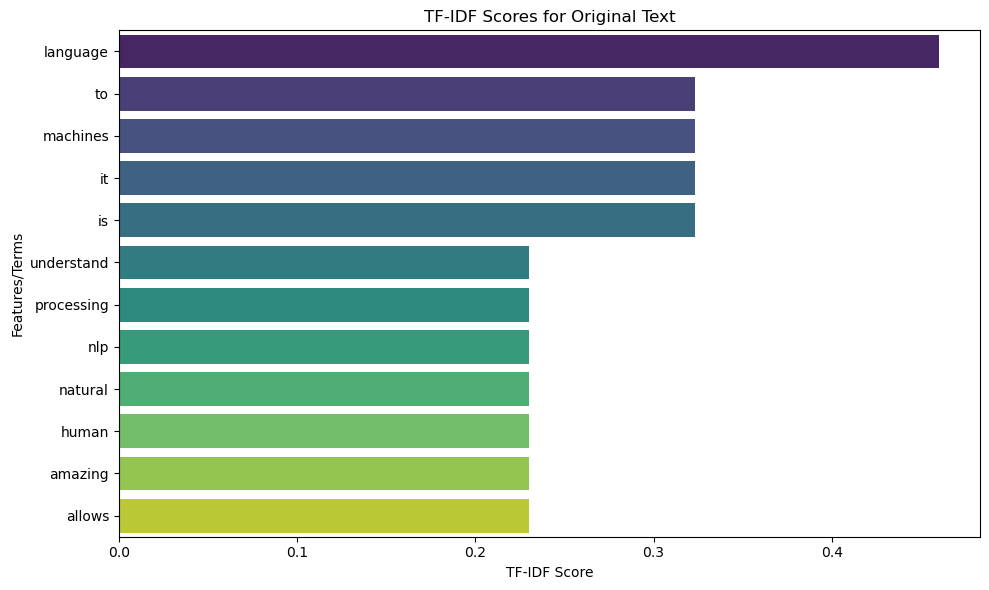

In [6]:
# Plotting TF-IDF Scores
plt.figure(figsize=(10, 6))

# Get scores for the first document (original text)
doc1_scores = tfidf_matrix[0]

# Filter out non-zero scores
indices = np.where(doc1_scores > 0)[0]
features = [tfidf_features[i] for i in indices]
scores = [doc1_scores[i] for i in indices]

# Sort features by score
sorted_indices = np.argsort(scores)[::-1]
sorted_features = [features[i] for i in sorted_indices]
sorted_scores = [scores[i] for i in sorted_indices]

sns.barplot(x=sorted_scores, y=sorted_features, palette='viridis')
plt.title('TF-IDF Scores for Original Text')
plt.xlabel('TF-IDF Score')
plt.ylabel('Features/Terms')
plt.tight_layout()
plt.savefig('outputs/tfidf_scores.png', dpi=300)
plt.show()

# Questions:

1. **What is Lowercasing and Tokenization?**
   Lowercasing converts all text to small letters to maintain consistency. Tokenization breaks down continuous text into individual units, effectively splitting sentences into words.

2. **Why do we remove stopwords and punctuation?**
   Stopwords (e.g., 'is', 'the', 'it') commonly appear in the English language but carry little semantic value. Removing them alongside punctuation reduces background noise and computational overhead.

3. **What is the difference between Stemming and Lemmatization?**
   Stemming algorithmically strips word endings to find the root form (often producing non-words like 'amaz'), whereas Lemmatization uses linguistic rules and vocabularies to return the actual dictionary base word (lemma).

4. **What is TF-IDF and how does it differ from Bag of Words?**
   Bag of Words just counts the sheer frequency of words in each document. TF-IDF (Term Frequency-Inverse Document Frequency) adjusts this count by the term's uniqueness across all documents, assigning higher weights to more meaningful and informative words.